In [1]:
from utils import get_svamp_df, get_gsm8k
from statistical_significance import compare_accuracies, compare_accuracies_v2, compare_accuracies_v3

import pandas as pd
import numpy as np

df = get_gsm8k()
df.head()

GSM8K
gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx
DP-Reflection
qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
deepseek-r1_1.5b.xlsx
ReAct
qwen3_1.7b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
llama3.2_1b.xlsx
ReWOO
gemma-3-27b-it.xlsx
qwen3_1.7b.xlsx
smollm2_360m.xlsx
qwen2-math_1.5b.xlsx
qwen3_0.6b.xlsx
qwen2.5_0.5b.xlsx
gemma3_1b.xlsx
deepseek-r1_1.5b.xlsx
llama3.2_1b.xlsx


,Dataset,Method,Model,question,target_answer,response,is_correct,input_tokens,output_tokens,total_tokens,reasoning,Error Class,Error Type
0,GSM8K,Direktes Prompting,gemma-3-27b-it,Janet‚Äôs ducks lay 16 eggs per day. She eats ...,Janet sells 16 - 3 - 4 = <<16-3-4=9>>9 duck eg...,Let $E$ be the number of eggs Janet's ducks la...,True,NaN,NaN,NaN,Let $E$ be the number of eggs Janet's ducks la...,NaN,NaN
1,GSM8K,Direktes Prompting,gemma-3-27b-it,A robe takes 2 bolts of blue fiber and half th...,It takes 2/2=<<2/2=1>>1 bolt of white fiber\nS...,Let the number of bolts of blue fiber be $B$ a...,True,NaN,NaN,NaN,Let the number of bolts of blue fiber be $B$ a...,NaN,NaN
2,GSM8K,Direktes Prompting,gemma-3-27b-it,Josh decides to try flipping a house. He buys...,The cost of the house and repairs came out to ...,Let the initial cost of the house be $C = \$80...,True,NaN,NaN,NaN,Let the initial cost of the house be $C = \$80...,NaN,NaN
3,GSM8K,Direktes Prompting,gemma-3-27b-it,James decides to run 3 sprints 3 times a week....,He sprints 3*3=<<3*3=9>>9 times\nSo he runs 9*...,Let $s$ be the number of sprints James runs ea...,True,NaN,NaN,NaN,Let $s$ be the number of sprints James runs ea...,NaN,NaN
4,GSM8K,Direktes Prompting,gemma-3-27b-it,"Every day, Wendi feeds each of her chickens th...","If each chicken eats 3 cups of feed per day, t...",Let $n$ be the number of chickens Wendi has. W...,True,NaN,NaN,NaN,Let $n$ be the number of chickens Wendi has. W...,NaN,NaN


# F1 Score

In [2]:
from collections import Counter
import re

# def normalize_answer(s):
#     """Lowercase, remove articles and extra spaces (but keep punctuation for tokenizer)."""
#     def lower(text): return text.lower()
#     def remove_articles(text): return re.sub(r'\b(a|an|the)\b', ' ', text)
#     def white_space_fix(text): return ' '.join(text.split())
#     return white_space_fix(remove_articles(lower(s)))

# def f1_score_tokenizer(prediction, ground_truth, tokenizer):
#     """
#     Compute F1 using a real tokenizer.
    
#     Args:
#         prediction (str): predicted text
#         ground_truth (str): reference text
#         tokenizer: a tokenizer object with a .tokenize() method
    
#     Returns:
#         float: F1 score
#     """
#     pred_norm = normalize_answer(str(prediction))
#     gt_norm = normalize_answer(str(ground_truth))
    
#     pred_tokens = tokenizer.tokenize(pred_norm)
#     gt_tokens = tokenizer.tokenize(gt_norm)
    
#     common = Counter(pred_tokens) & Counter(gt_tokens)
#     num_same = sum(common.values())
    
#     if num_same == 0:
#         return 0.0
    
#     precision = num_same / len(pred_tokens)
#     recall = num_same / len(gt_tokens)
#     return 2 * precision * recall / (precision + recall)


import re
import string

def normalize_answer(s):
    def remove_articles(text):
        return re.sub(r'\b(a|an|the)\b', ' ', text)

    def white_space_fix(text):
        return ' '.join(text.split())

    def remove_punc(text):
        return ''.join(ch for ch in text if ch not in string.punctuation)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_articles(remove_punc(lower(s))))

def f1_score(prediction, ground_truth):
    pred_tokens = normalize_answer(str(prediction)).split()
    gold_tokens = normalize_answer(str(ground_truth)).split()
    common = set(pred_tokens) & set(gold_tokens)
    num_same = sum(min(pred_tokens.count(w), gold_tokens.count(w)) for w in common)
    if num_same == 0:
        return 0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)
    return 2 * precision * recall / (precision + recall)

def recall(prediction, ground_truth):
    pred_tokens = normalize_answer(str(prediction)).split()
    gold_tokens = normalize_answer(str(ground_truth)).split()
    common = set(pred_tokens) & set(gold_tokens)
    num_same = sum(min(pred_tokens.count(w), gold_tokens.count(w)) for w in common)
    if num_same == 0:
        return 0
    recall = num_same / len(gold_tokens)
    return recall


def precision(prediction, ground_truth):
    pred_tokens = normalize_answer(str(prediction)).split()
    gold_tokens = normalize_answer(str(ground_truth)).split()
    common = set(pred_tokens) & set(gold_tokens)
    num_same = sum(min(pred_tokens.count(w), gold_tokens.count(w)) for w in common)
    if num_same == 0:
        return 0
    precision = num_same / len(pred_tokens)
    return precision


In [4]:
df["f1_score"] = df.apply(
    lambda row: f1_score(row["reasoning"], row["target_answer"]),
    axis=1
)

df["recall"] = df.apply(
    lambda row: recall(row["reasoning"], row["target_answer"]),
    axis=1
)

df["precision"] = df.apply(
    lambda row: precision(row["reasoning"], row["target_answer"]),
    axis=1
)

In [6]:
df_f1_score = df.groupby(["Model", "Method"]).agg({
    "is_correct": "mean",
    "f1_score": "mean",
    "recall": "mean",
    "precision": "mean"
}).reset_index().sort_values(by=("is_correct"), ascending=False)

df_f1_score

,Model,Method,is_correct,f1_score,recall,precision
3,gemma-3-27b-it,Direktes Prompting,0.973333,0.289704,0.638353,0.200351
4,gemma-3-27b-it,ReWOO,0.890000,0.261012,0.413882,0.200621
20,qwen3:1.7b,DP-Reflection,0.873333,0.038455,0.799029,0.019831
22,qwen3:1.7b,ReAct,0.853333,0.146077,0.718644,0.084407
10,qwen2-math:1.5b,Direktes Prompting,0.823333,0.277076,0.650741,0.185151
2,deepseek-r1:1.5b,ReWOO,0.773333,0.100015,0.779580,0.054494
23,qwen3:1.7b,ReWOO,0.743333,0.092342,0.744778,0.050201
1,deepseek-r1:1.5b,Direktes Prompting,0.733333,0.290898,0.573685,0.211490
16,qwen3:0.6b,DP-Reflection,0.686667,0.042073,0.783675,0.021773
21,qwen3:1.7b,Direktes Prompting,0.666667,0.218998,0.651809,0.154356


In [7]:
# Jetzt kannst du normal zugreifen
correlation = df_f1_score["is_correct"].corr(df_f1_score["f1_score"])
print("F1 Score Correlation:", correlation)

correlation = df_f1_score["is_correct"].corr(df_f1_score["recall"])
print("Recall Correlation:", correlation)

correlation = df_f1_score["is_correct"].corr(df_f1_score["precision"])
print("Precision Correlation:", correlation)

F1 Score Correlation: -0.3522548698628839
Recall Correlation: 0.6305732181262056
Precision Correlation: -0.504109597927453


In [9]:
df_small_f1 = df_f1_score.groupby(["Method"]).agg({
    "is_correct": "mean",
    "f1_score": "mean",
    "recall": "mean",
    "precision": "mean"
}).reset_index().sort_values(by=("is_correct"), ascending=False)
df_small_f1

,Method,is_correct,f1_score,recall,precision
0,DP-Reflection,0.642500,0.064035,0.764974,0.034285
1,Direktes Prompting,0.595185,0.273289,0.618007,0.194429
2,ReAct,0.474167,0.216284,0.512574,0.226512
3,ReWOO,0.362593,0.196525,0.532439,0.154429


In [12]:
records = []
for m in df_f1_score["Method"].unique():
    df_tmp = df_f1_score[df_f1_score["Method"] == m]
    records.append({
        "Method": m,
        "F1 Score Correlation": df_tmp["is_correct"].corr(df_tmp["f1_score"]),
        "Recall Correlation": df_tmp["is_correct"].corr(df_tmp["recall"]),
        "Precision Correlation": df_tmp["is_correct"].corr(df_tmp["precision"])
    })

df_f1_t = pd.DataFrame.from_records(records)
df_f1_t

,Method,F1 Score Correlation,Recall Correlation,Precision Correlation
0,Direktes Prompting,-0.124657,0.602853,-0.215656
1,ReWOO,-0.604165,0.526788,-0.668678
2,DP-Reflection,-0.930959,0.948594,-0.934739
3,ReAct,-0.955988,0.972443,-0.974954


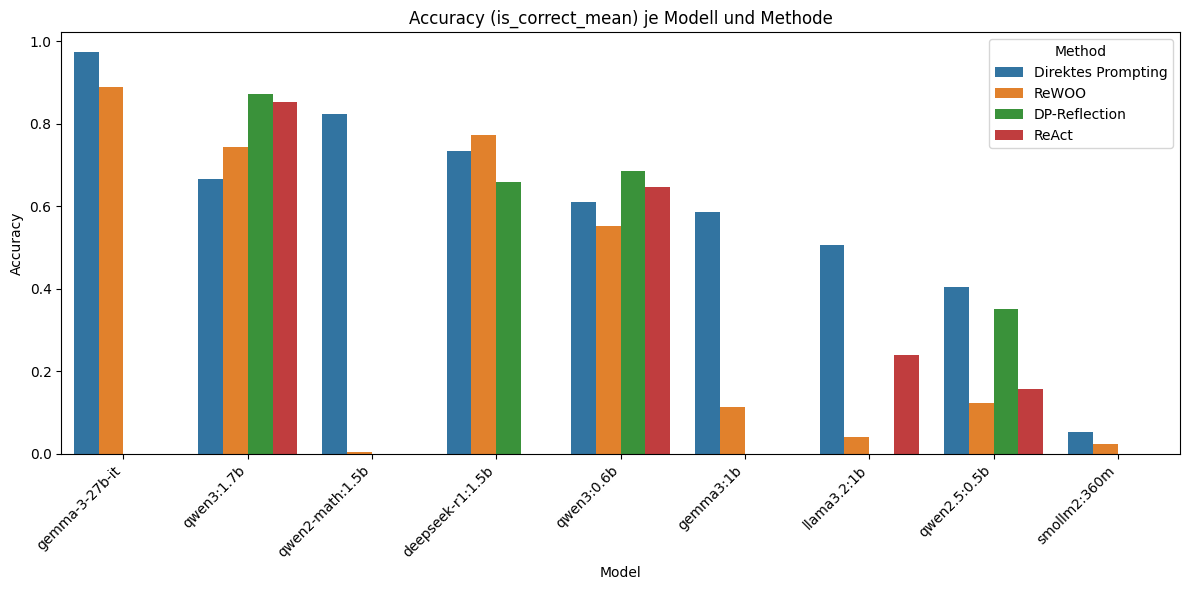

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=df_f1_score, x='Model_', y='is_correct_mean', hue='Method_')
plt.xticks(rotation=45, ha='right')
plt.title('Accuracy (is_correct_mean) je Modell und Methode')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.legend(title='Method')
plt.tight_layout()
plt.show()


RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

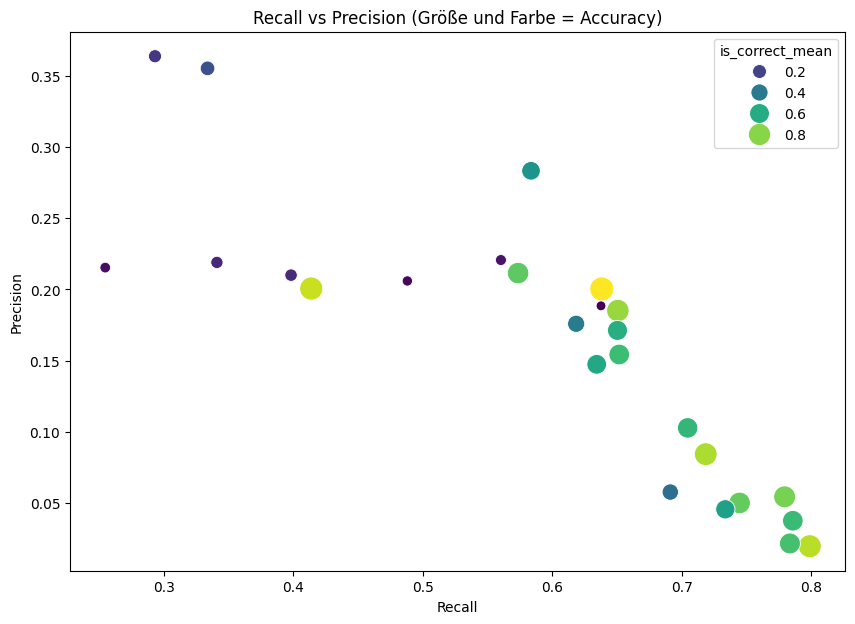

In [14]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=df_f1_score, x='recall_mean', y='precision_mean', size='is_correct_mean', hue='is_correct_mean', palette='viridis', sizes=(50, 300))
plt.title('Recall vs Precision (Größe und Farbe = Accuracy)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.colorbar(label='Accuracy')
plt.show()


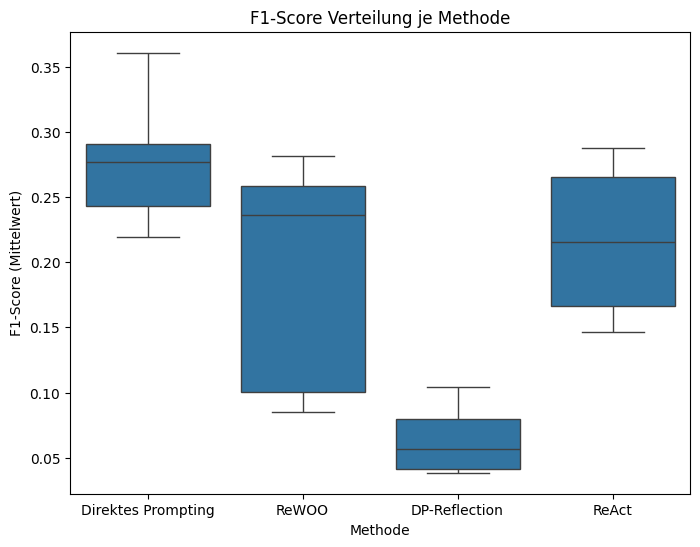

In [15]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df_f1_score, x='Method_', y='f1_score_mean')
plt.title('F1-Score Verteilung je Methode')
plt.xlabel('Methode')
plt.ylabel('F1-Score (Mittelwert)')
plt.show()


In [3]:
df["Model"].unique()

array(['gemma-3-27b-it', 'qwen3:1.7b', 'smollm2:360m', 'qwen2-math:1.5b',
       'qwen3:0.6b', 'qwen2.5:0.5b', 'gemma3:1b', 'deepseek-r1:1.5b',
       'llama3.2:1b'], dtype=object)